<a href="https://colab.research.google.com/github/martonhajdu/martonhajdu-DataScience-GenAI-Submissions/blob/main/4_01_Decision_Trees_COMPLETED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

# Creating a dataframe of features
x_values = pd.DataFrame(data.data, columns=data.feature_names)

from sklearn.preprocessing import MinMaxScaler

# Creating the MinMaxScaler object
scaler = MinMaxScaler()

# fit and transform the data
normal_data = scaler.fit_transform(x_values)

# recreate x_values using the scaled data and original features
x_values = pd.DataFrame(normal_data, columns=data.feature_names)

# create y value
y_value = pd.DataFrame(data.target, columns=['class'])
y_value = np.ravel(y_value)

x_values.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


In [ ]:
# Train-Test split

# split data into training and test
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(x_values, y_value, test_size=0.2, random_state=1984, stratify=y_value)
# stratify=y_values -> makes sure there is a proportionate number of each class in the training data

# print the shapes
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [ ]:
# Decision Trees

from sklearn.tree import DecisionTreeClassifier as DTC

# the model - unfitted/untrained
DTC_algo = DTC()
DTC_algo

DecisionTreeClassifier()

In [ ]:
DTC_model = DTC_algo.fit(X_train, Y_train)
DTC_model

DecisionTreeClassifier()

In [ ]:
# Seing how this model performs
from sklearn.metrics import accuracy_score

# predicting the test data
predict = DTC_model.predict(X_test)

# seperating the first 5 predictions and the first 5 real values in Y_test
for i in range(5):
  print(f'Predicted: {round(predict[i],2)}')
  print(f'Real: {Y_test[i]}')
  print('\n')

print('\n')

print(f'Accuracy: {round(accuracy_score(Y_test, predict),2)}')

Predicted: 0
Real: 0


Predicted: 0
Real: 0


Predicted: 0
Real: 0


Predicted: 0
Real: 0


Predicted: 1
Real: 1




Accuracy: 0.95


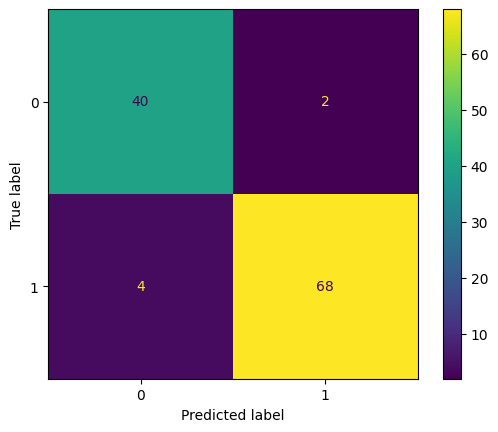

In [ ]:
# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay as CM

CM.from_predictions(Y_test, predict)

In [ ]:
# extracting the scores
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_score, _ = precision_recall_fscore_support(Y_test, predict, average='micro')

print(f'Micro-averaged Precision: {round(precision,2)}')
print(f'Micro-averaged Recall: {round(recall,2)}')
print(f'Micro-averaged F1-Score: {round(f1_score,2)}')
print('\n')

precision, recall, f1_score, _ = precision_recall_fscore_support(Y_test, predict, average='macro')

print(f'Macro-averaged Precision: {round(precision,2)}')
print(f'Macro-averaged Recall: {round(recall,2)}')
print(f'Macro-averaged F1-Score: {round(f1_score,2)}')

Micro-averaged Precision: 0.95
Micro-averaged Recall: 0.95
Micro-averaged F1-Score: 0.95


Macro-averaged Precision: 0.94
Macro-averaged Recall: 0.95
Macro-averaged F1-Score: 0.94


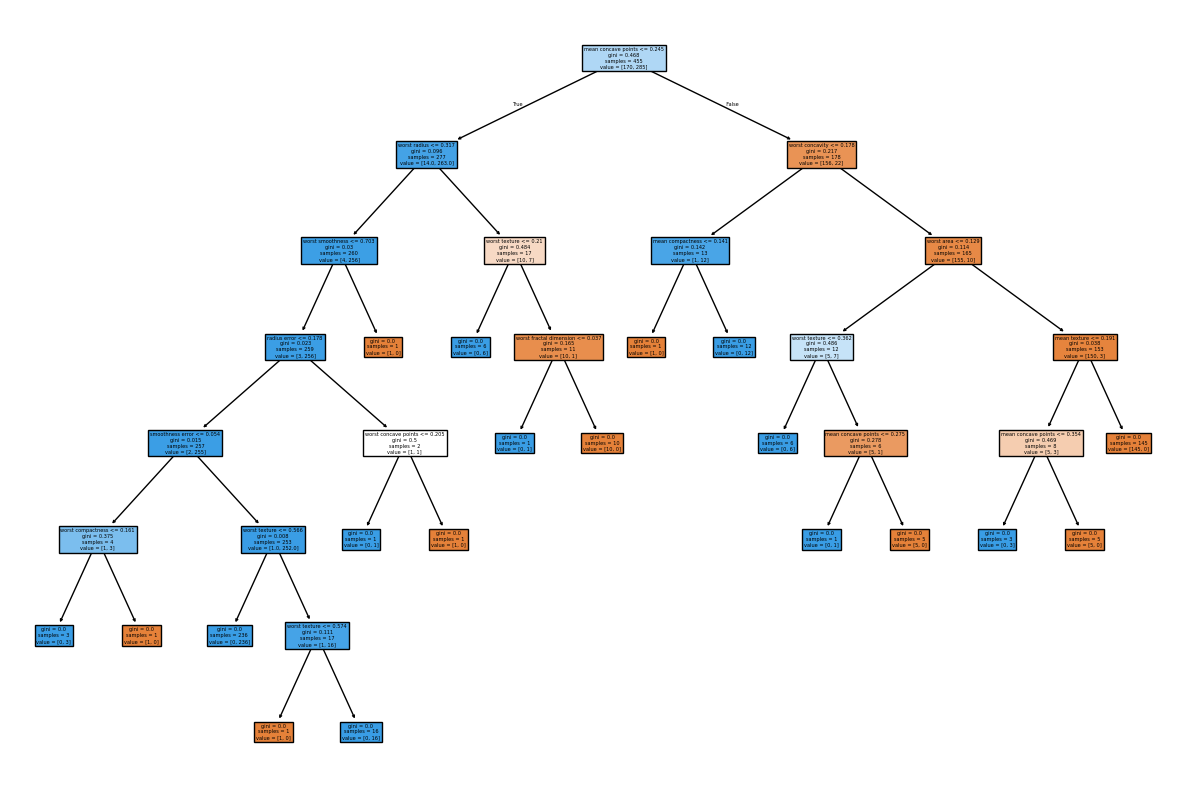

In [ ]:
# Visualizing the tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(DTC_model, filled=True, feature_names=X_train.columns)
plt.show()

In [ ]:
# tree is maybe an overfit
# searching hyperparamteres to see what would be best

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# list of parameters we will tune
# Some are fixed valued, some are distributions
tuned_parameters ={
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(3, 9),
    'min_samples_split': randint(3, 9),
    'max_features': ['sqrt', 'log2', None]
}
# we will tune against f1_macro/recall_macro (to find the best choice)
#score = 'f1_macro'
score = 'recall_macro'

print(f'Tuning hyperparameters for {score}')
print('\n')

# do the search using 5 folds/chunks
clf = RandomizedSearchCV(DTC(), tuned_parameters, cv=5, random_state=1984,
                         scoring = score, n_iter=20, refit=True)

# pass the data to fit/train
clf.fit(X_train, Y_train)

print(f'Best parameters: {clf.best_params_}')
print(f'Best score: {clf.best_score_}')

Tuning hyperparameters for recall_macro


Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_split': 5}
Best score: 0.934829721362229


In [ ]:
# training the model again, but using the above hyperparameters
DTC_algo = DTC(**clf.best_params_) #get the best parameters from grid search
DTC_model = DTC_algo.fit(X_train, Y_train)

In [ ]:
# predict the test data
predict = DTC_model.predict(X_test)

# seperate the first 5 predictions from the first 5 real values in Y_test
for i in range(5):
  print(f'Predcited: {round(predict[i],2)}')
  print(f'Real: {Y_test[i]}')
  print('\n')

print('\n')

print(f'Accuracy: {round(accuracy_score(Y_test, predict),2)}')

Predcited: 0
Real: 0


Predcited: 0
Real: 0


Predcited: 0
Real: 0


Predcited: 0
Real: 0


Predcited: 1
Real: 1




Accuracy: 0.95


Micro-averaged Precision: 0.95
Micro-averaged Recall: 0.95
Micro-averaged F1-score: 0.95


Macro-averaged Precision: 0.94
Macro-averaged Recall: 0.95
Macro-averaged F1-score: 0.94




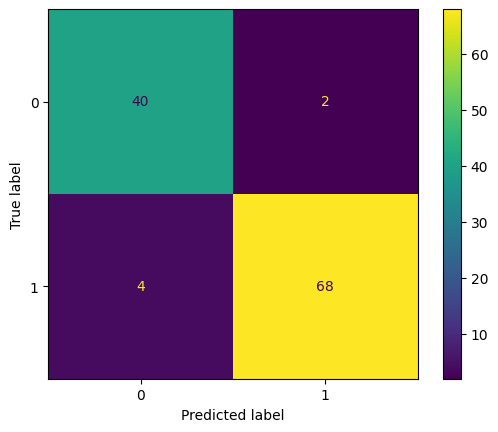

In [ ]:
# create a confusion matrix
CM.from_predictions(Y_test, predict)

# Calculate precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(Y_test, predict, average='micro')

print(f"Micro-averaged Precision: {round(precision, 2)}")
print(f"Micro-averaged Recall: {round(recall, 2)}")
print(f"Micro-averaged F1-score: {round(f1_score, 2)}")
print("\n")

precision, recall, f1_score, _ = precision_recall_fscore_support(Y_test, predict, average='macro')

print(f"Macro-averaged Precision: {round(precision, 2)}")
print(f"Macro-averaged Recall: {round(recall, 2)}")
print(f"Macro-averaged F1-score: {round(f1_score, 2)}")
print("\n")

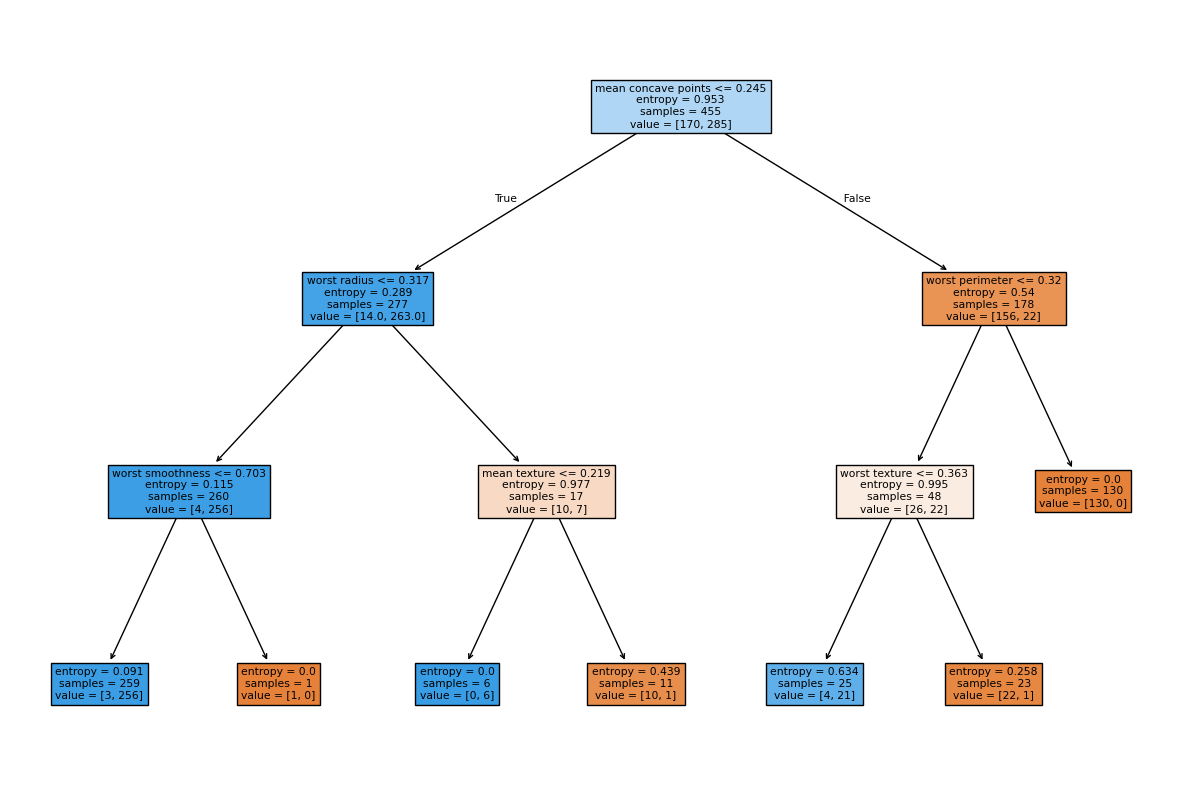

In [ ]:
# plotting tree
plt.figure(figsize=(15, 10))
plot_tree(DTC_model, filled=True, feature_names=X_train.columns)
plt.show()